# Opto effect visualiser (QC)

Quick visual check of optogenetic effects. **Not a statistical results notebook** —
pooled views are for *seeing* an effect, not *claiming* one. For across-animal claims
use `compute_per_animal_stats` + `compute_group_comparison`, not the pooled panels here.

Spine (same for every contrast): **filter → (pool) → split → compare**.

Two choices are always explicit at the top — never silently defaulted:
- `CONTRAST`: which two groups are compared.
- `BASELINE`: how the opto-off baseline is defined (carry-over handling).


## 0. Imports


In [1]:
# shared_setup provides np, plt, palette/style, data structures, and the
# behav_utils analysis + plotting functions (same convention as NB 01/02/10/11).
from shared_setup import *
apply_style()

# 05-specific extras not in shared_setup:
from analysis.opto import assign_opto_phases

# The ten heuristic SBI stats. accuracy + psychometric are shown as their own
# panels; the 'remaining stats' panel shows the other eight.
SBI_STATS = ['accuracy','psychometric','recency','stimulus_recency','win_stay',
             'lose_shift','side_bias','stimulus_sensitivity','choice_entropy','perseveration']
REMAINING_STATS = [s for s in SBI_STATS if s not in ('accuracy','psychometric')]


## 1. Load data

Real path first. If the snapshot isn't mounted (e.g. running off-cluster), set
`USE_SYNTHETIC = True` to exercise the spine on a fake opto cohort — the synthetic
branch is **only** for checking the code runs; never read science off it.


In [2]:
USE_SYNTHETIC = False   # True → fake cohort to test the spine without data mounted

if not USE_SYNTHETIC:
    experiment, info = load_data()
    print('loaded:', info.get('mode'), '| animals:', list(experiment.animals.keys())[:10])
else:
    # ---- synthetic opto cohort (REPLACE with real data; QC of code only) ----
    from datetime import date, timedelta
    from behav_utils.data.structures import (
        SessionData, SessionMetadata, TrialData, AnimalData, ExperimentData)

    def _make_opto_session(idx, animal_id, n=400, opto_frac=0.30, opto_bias=0.12,
                           masking=False, het=True, rng=None):
        rng = rng or np.random.default_rng(idx)
        stim = rng.uniform(-1, 1, n); cat = (stim > 0).astype(int)
        opto_on = rng.random(n) < opto_frac
        p = 1/(1+np.exp(-4*stim))
        shift = 0.0 if (masking or not het) else opto_bias
        p_eff = np.clip(p + np.where(opto_on, shift, 0.0), 0.02, 0.98)
        choice = (rng.random(n) < p_eff).astype(float)
        abort = rng.random(n) < 0.04; choice[abort] = np.nan
        correct = (choice == cat); correct[np.isnan(choice)] = False
        outcome = np.where(abort,'Abort',np.where(correct,'Correct','Incorrect'))
        trials = TrialData(trial_number=np.arange(1,n+1), stimulus=stim, category=cat,
            choice=choice, choice_raw=choice.copy(), correct=correct, outcome=outcome,
            reaction_time=np.abs(rng.normal(300,90,n)), abort=abort, opto_on=opto_on,
            distribution=np.array(['uniform']*n))
        meta = SessionMetadata(fields={'animal_id':animal_id,'stage':'Full_Task_Cont',
            'protocol':'Synthetic','stim_range_min':-1.0,'stim_range_max':1.0})
        return SessionData(session_id=f'{animal_id}_S{idx:03d}', session_idx=idx,
            date=date(2025,1,1)+timedelta(days=idx), metadata=meta, trials=trials,
            masking=masking)

    def _make_animal(animal_id, het=True):
        sess = ([_make_opto_session(i, animal_id, masking=True, het=het) for i in range(2)]
                + [_make_opto_session(i, animal_id, masking=False, het=het) for i in range(2,8)])
        return AnimalData(animal_id=animal_id, sessions=sess,
                          metadata={'genotype': 'het' if het else 'wt'})

    experiment = ExperimentData(metadata={'cohort':'synthetic_opto_demo'})
    for aid, het in [('SS_HET1',True),('SS_HET2',True),('SS_WT1',False)]:
        experiment.add_animal(_make_animal(aid, het))
    info = {'mode':'synthetic'}
    print('synthetic cohort:', list(experiment.animals.keys()))


Loaded snapshot: 22 animals, 1102 sessions (exported 2026-05-18)
loaded: snapshot | animals: ['SS01', 'SS02', 'SS04', 'SS05', 'SS06', 'SS07', 'SS08', 'SS09', 'SS10', 'SS11']


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:192: UserWarning: Snapshot is 313h old (exported 2026-05-18T19:50:55.891447+00:00). Re-export if new sessions have been collected.
  experiment, meta = load_snapshot(
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:192: UserWarning: Config has changed since snapshot was exported. Re-export if column mappings changed.
  experiment, meta = load_snapshot(


## 2. The spine

`pool_arrays` concatenates masked `(stimulus, choice, category)` across sessions.
`split_on_off` is where `BASELINE` lives:
- `'all'` → every non-opto trial is baseline (simplest; biased toward *shrinking* the
  effect because carry-over trials are still recovering).
- `'clean'` → drop the 1st and 2nd non-opto trials after each opto run (`delta=1,2`),
  so the baseline is genuinely opto-free.

Neither is 'right' — the point is to see both. Flip `BASELINE` and compare.


In [3]:
def pool_arrays(sessions, mask_fn):
    """Concatenate masked (stimulus, choice, category) across sessions."""
    S, C, K = [], [], []
    for s in sessions:
        t = s.trials
        m = mask_fn(t) & t.valid_mask
        S.append(t.stimulus[m]); C.append(t.choice[m].astype(float)); K.append(t.category[m])
    if not S:
        return np.array([]), np.array([]), np.array([])
    return np.concatenate(S), np.concatenate(C), np.concatenate(K)

def split_on_off(sessions, baseline):
    """Group A = opto-on trials; Group B = opto-off baseline (per `baseline`)."""
    on = pool_arrays(sessions, lambda t: opto_mask(t, delta=0))
    if baseline == 'all':
        off = pool_arrays(sessions, lambda t: opto_mask(t, delta='control'))
    elif baseline == 'clean':
        def clean_off(t):
            return (opto_mask(t, delta='control')
                    & ~opto_mask(t, delta=1) & ~opto_mask(t, delta=2))
        off = pool_arrays(sessions, clean_off)
    else:
        raise ValueError("BASELINE must be 'all' or 'clean'")
    return on, off


## 3. Choose the contrast and baseline

`CONTRAST`:
- `'within'` — opto-on vs opto-off trials, within this animal's opto sessions.
- `'opto_vs_masking'` — opto sessions vs masking (light-only) sessions, opto-on trials.
- `'het_vs_wt'` — the opto-on−off effect in HET vs in WT animals.

Both choices are explicit, every run.


In [4]:
CONTRAST = 'within'          # 'within' | 'opto_vs_masking' | 'het_vs_wt'
BASELINE = 'clean'           # 'all' | 'clean'  — always set this by hand
ANIMAL_ID = list(experiment.animals.keys())[0]   # one animal to dive in
ANIMAL_ID = 'SS14'

PHASE = 'expert_uniform_opto'    # which assign_opto_phases bucket to pull opto sessions from

print(f'CONTRAST={CONTRAST}  BASELINE={BASELINE}  ANIMAL={ANIMAL_ID}  PHASE={PHASE}')


CONTRAST=within  BASELINE=clean  ANIMAL=SS14  PHASE=expert_uniform_opto


## 4. Filter → pool → split

`assign_opto_phases` partitions one animal's sessions; we pull the opto sessions from
`PHASE` and (for the masking contrast) the masking sessions. `SESSION_SUBSET` lets you
pool a chosen subset or a single session instead of all of them.


In [5]:
animal = experiment.animals[ANIMAL_ID]
phases = assign_opto_phases(animal.sessions)
opto_sessions = phases.get(PHASE, [])
masking_sessions = phases.get('masking', [])
print(f'{ANIMAL_ID}: {len(opto_sessions)} opto sessions in {PHASE!r}, '
      f'{len(masking_sessions)} masking sessions')

# Optional: restrict to a subset (or one) session. None = use all.
SESSION_SUBSET = None        # e.g. [0, 2] picks those session_idx values
def _subset(sessions):
    if SESSION_SUBSET is None:
        return sessions
    return [s for s in sessions if s.session_idx in SESSION_SUBSET]
opto_sessions = _subset(opto_sessions)

# Build the two comparison groups per CONTRAST.
if CONTRAST == 'within':
    (s_a,c_a,k_a), (s_b,c_b,k_b) = split_on_off(opto_sessions, BASELINE)
    LABEL_A, LABEL_B = 'opto-on', f'opto-off ({BASELINE})'
elif CONTRAST == 'opto_vs_masking':
    # opto-on trials in opto sessions vs opto-on-equivalent (all valid) in masking sessions
    s_a,c_a,k_a = pool_arrays(opto_sessions,   lambda t: opto_mask(t, delta=0))
    s_b,c_b,k_b = pool_arrays(masking_sessions, lambda t: t.valid_mask)
    LABEL_A, LABEL_B = 'opto (laser)', 'masking (light only)'
elif CONTRAST == 'het_vs_wt':
    # handled in the dedicated het/wt cell below (needs all animals); placeholder here
    s_a=c_a=k_a=s_b=c_b=k_b=np.array([])
    LABEL_A, LABEL_B = 'HET effect', 'WT effect'
else:
    raise ValueError(CONTRAST)

if CONTRAST != 'het_vs_wt':
    print(f'group A ({LABEL_A}): {len(s_a)} trials | group B ({LABEL_B}): {len(s_b)} trials')


SS14: 5 opto sessions in 'expert_uniform_opto', 2 masking sessions
group A (opto-on): 515 trials | group B (opto-off (clean)): 653 trials


## 5. Compare — psychometric, update matrix, remaining stats

Three panels for the two pooled groups. (For `het_vs_wt`, skip to cell 6.)


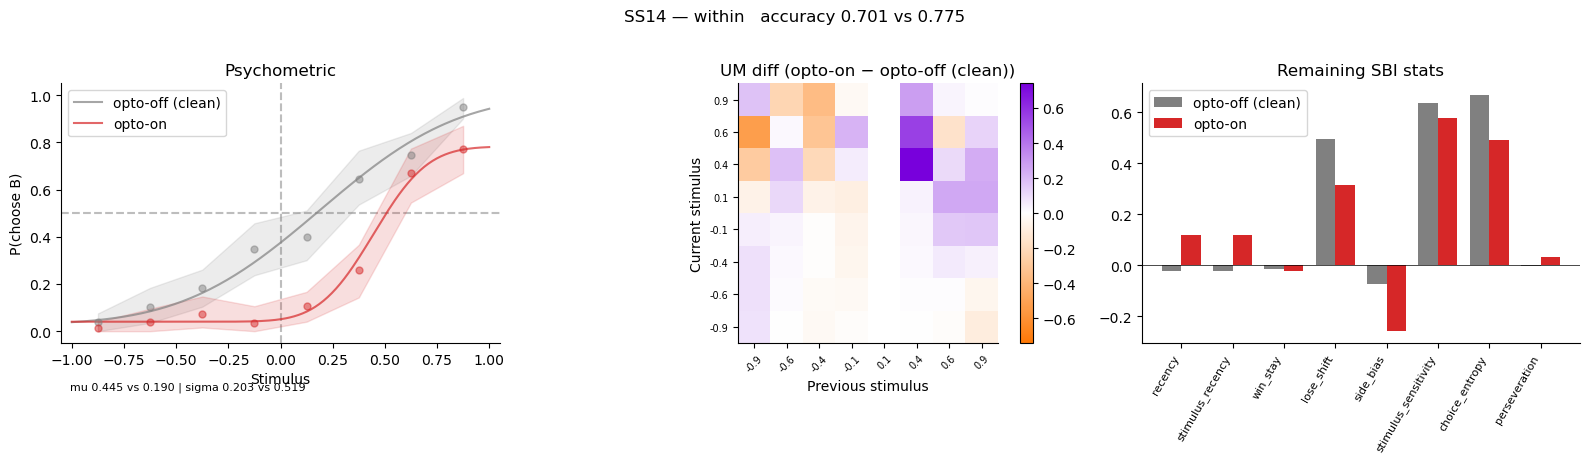

In [6]:
def _compare_panel(s_a,c_a,k_a, s_b,c_b,k_b, label_a, label_b, title=''):
    if len(c_a) < 20 or len(c_b) < 20:
        print(f'Not enough trials to compare: A={len(c_a)}, B={len(c_b)} '
              f'(need >=20 each). Check ANIMAL_ID / PHASE / SESSION_SUBSET.')
        return None, None
    r_a = compute_psychometric((s_a, c_a), n_bootstrap=300)
    r_b = compute_psychometric((s_b, c_b), n_bootstrap=300)
    um_a,_,_ = compute_update_matrix(s_a, c_a, k_a)
    um_b,_,_ = compute_update_matrix(s_b, c_b, k_b)
    d_a = compute_summary_stats(c_a, s_a, k_a, stat_names=SBI_STATS, return_dict=True)
    d_b = compute_summary_stats(c_b, s_b, k_b, stat_names=SBI_STATS, return_dict=True)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    plot_psychometric(r_b, ax=axes[0], color='gray', label=label_b)
    plot_psychometric(r_a, ax=axes[0], color='C3',   label=label_a)
    axes[0].legend(loc='upper left'); axes[0].set_title('Psychometric')
    pa, pb = r_a['params'], r_b['params']
    axes[0].text(0.02,-0.18,f"mu {pa['mu']:.3f} vs {pb['mu']:.3f} | "
                            f"sigma {pa['sigma']:.3f} vs {pb['sigma']:.3f}",
                 transform=axes[0].transAxes, fontsize=8)
    plot_um(um_a - um_b, ax=axes[1], title=f'UM diff ({label_a} − {label_b})')
    x = np.arange(len(REMAINING_STATS)); w = 0.38
    axes[2].bar(x-w/2, [d_b[k] for k in REMAINING_STATS], w, label=label_b, color='gray')
    axes[2].bar(x+w/2, [d_a[k] for k in REMAINING_STATS], w, label=label_a, color='C3')
    axes[2].set_xticks(x); axes[2].set_xticklabels(REMAINING_STATS, rotation=60, ha='right', fontsize=8)
    axes[2].axhline(0, color='k', lw=0.5); axes[2].legend(); axes[2].set_title('Remaining SBI stats')
    acc_a = float(np.mean(c_a == k_a)); acc_b = float(np.mean(c_b == k_b))
    fig.suptitle(f'{title}   accuracy {acc_a:.3f} vs {acc_b:.3f}', y=1.02)
    fig.tight_layout(); plt.show()
    return d_a, d_b

if CONTRAST != 'het_vs_wt':
    _ = _compare_panel(s_a,c_a,k_a, s_b,c_b,k_b, LABEL_A, LABEL_B,
                       title=f'{ANIMAL_ID} — {CONTRAST}')


## 6. HET vs WT (across animals)

This is the one contrast that is **across animals**, so it is computed per animal and
then grouped — the opto-on−off effect is one number per animal. Pooling trials across
animals would assume trial-level independence and inflate significance; for a real
claim use `compute_per_animal_stats` + `compute_group_comparison`. This panel is the
eyeball version of that.


In [ ]:
def _animal_effect(animal, stat, baseline):
    """opto-on minus opto-off for one stat, one animal (pooled within animal)."""
    ph = assign_opto_phases(animal.sessions)
    opto_s = ph.get(PHASE, [])
    if not opto_s: return np.nan
    (sa,ca,ka),(sb,cb,kb) = split_on_off(opto_s, baseline)
    if len(ca) < 20 or len(cb) < 20: return np.nan
    da = compute_summary_stats(ca, sa, ka, stat_names=[stat], return_dict=True)
    db = compute_summary_stats(cb, sb, kb, stat_names=[stat], return_dict=True)
    return float(da[stat]) - float(db[stat])

if CONTRAST == 'het_vs_wt':
    stat = 'accuracy'   # pick the stat whose opto effect you want to compare across genotype
    het, wt = {}, {}
    for aid, a in	 experiment.animals.items():
        g = getattr(a, 'genotype', 'unknown')
        eff = _animal_effect(a, stat, BASELINE)
        if np.isnan(eff): continue
        (het if g == 'het' else wt if g == 'wt' else {}).update({aid: eff})
    print('HET effects:', het); print('WT effects:', wt)
    fig, ax = plt.subplots(figsize=(5,4))
    for i,(grp,col) in enumerate([(het,'C3'),(wt,'gray')]):
        vals = list(grp.values())
        ax.scatter(np.full(len(vals), i)+np.random.uniform(-0.05,0.05,len(vals)), vals,
                   color=col, s=40)
        if vals: ax.hlines(np.mean(vals), i-0.2, i+0.2, color=col, lw=2)
    ax.set_xticks([0,1]); ax.set_xticklabels(['HET','WT'])
    ax.axhline(0, color='k', lw=0.5); ax.set_ylabel(f'opto-on − off  ({stat}, {BASELINE})')
    ax.set_title('Opto effect by genotype (per-animal)'); plt.show()
    print('\nNOTE: n per group is tiny — eyeball only. Real claim: compute_group_comparison.')
